## Import packages

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

In [49]:
df = pd.read_csv("../data/PJME_hourly.csv")
df = df.set_index("Datetime")
df.index = pd.to_datetime(df.index)

In [50]:
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [51]:
df.tail()

,PJME_MW
Datetime,
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0
2018-01-01 23:00:00,40164.0
2018-01-02 00:00:00,38608.0


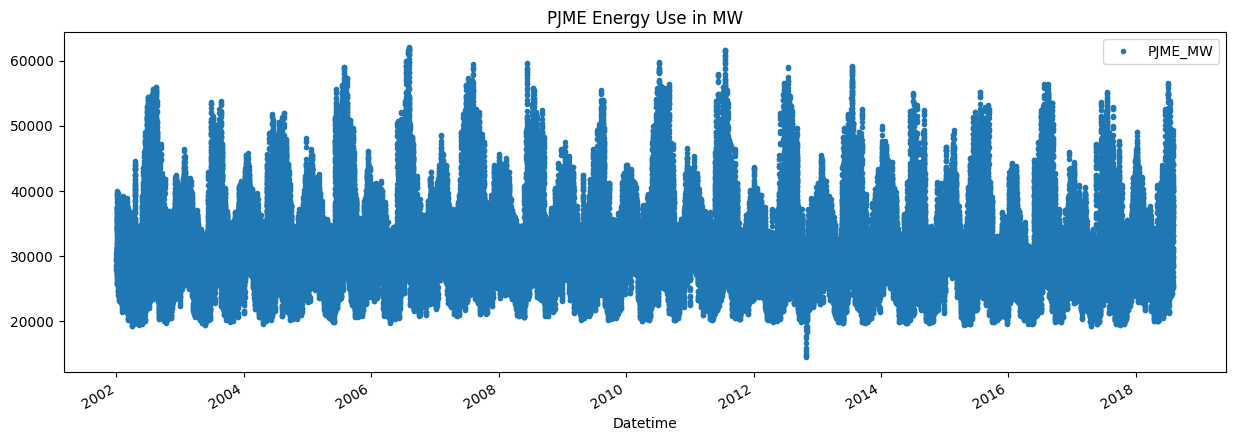

In [52]:
color_pal = sns.color_palette()

df.plot(style='.', 
        figsize=(15, 5), 
        color=color_pal[0], 
        title='PJME Energy Use in MW')
plt.show()

## Train / Test Split

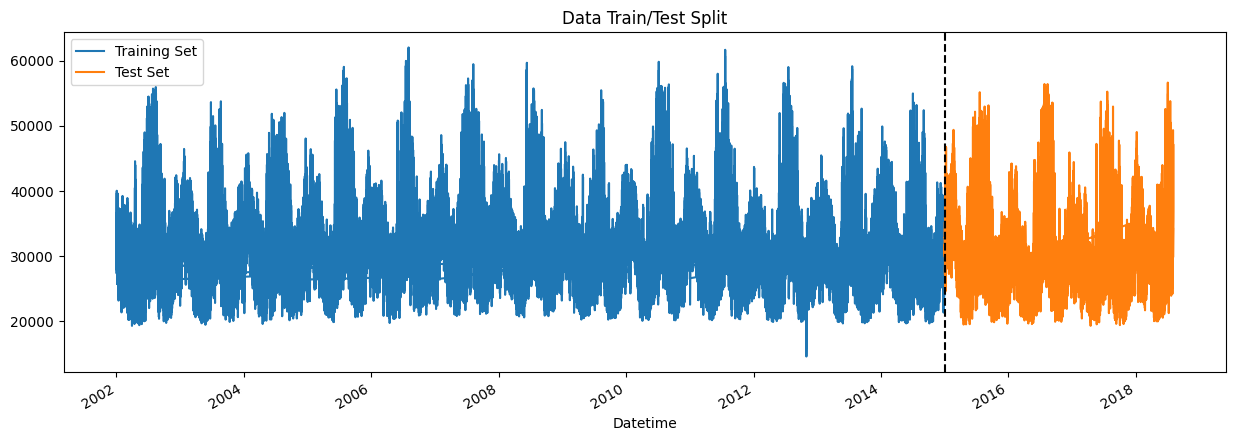

In [53]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

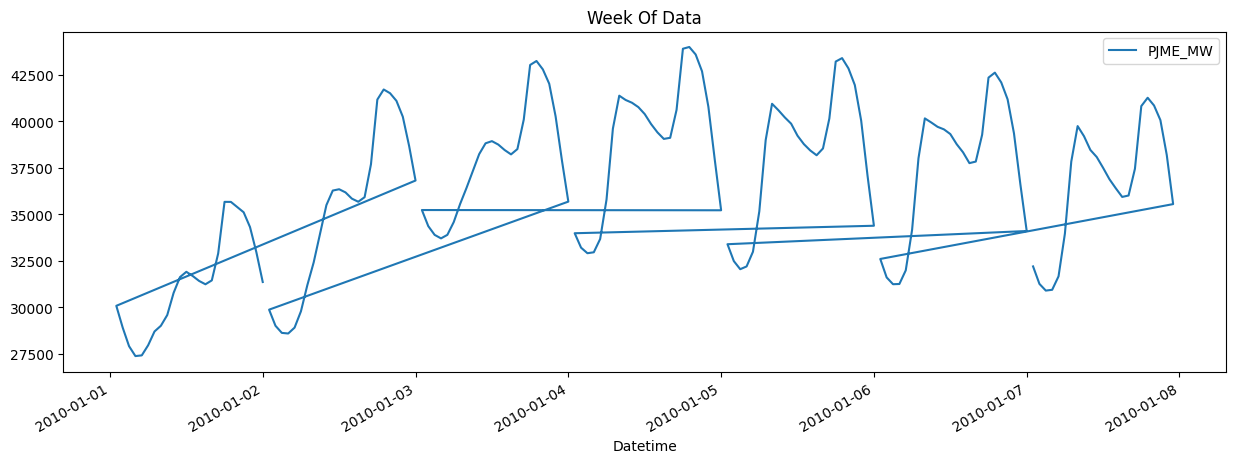

In [54]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

## Feature Creation

In [55]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

## Visualize Feature / Target Relationship

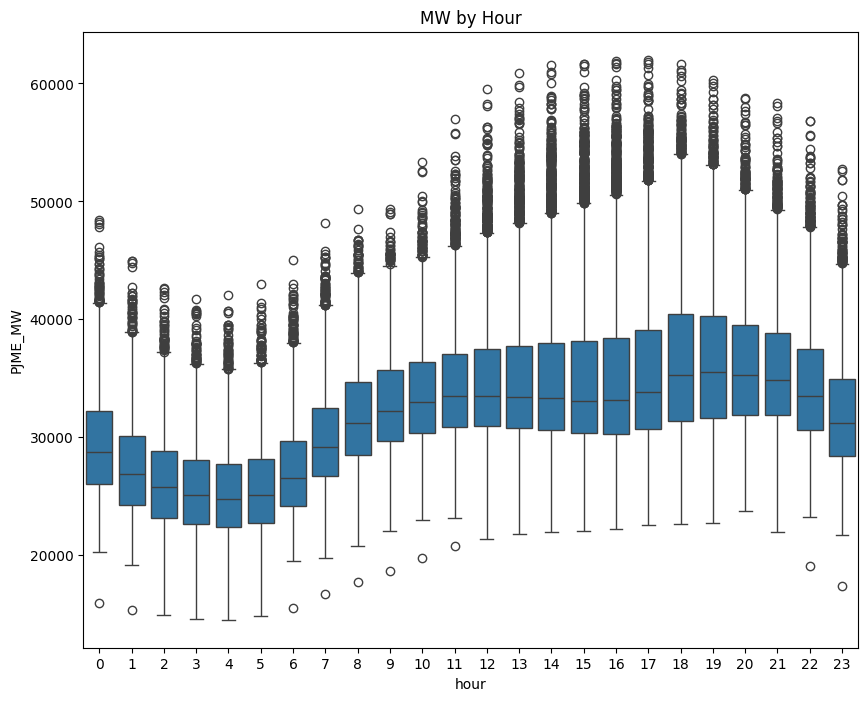

In [56]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()

C:\Users\zzami\AppData\Local\Temp\ipykernel_19964\2202713226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')


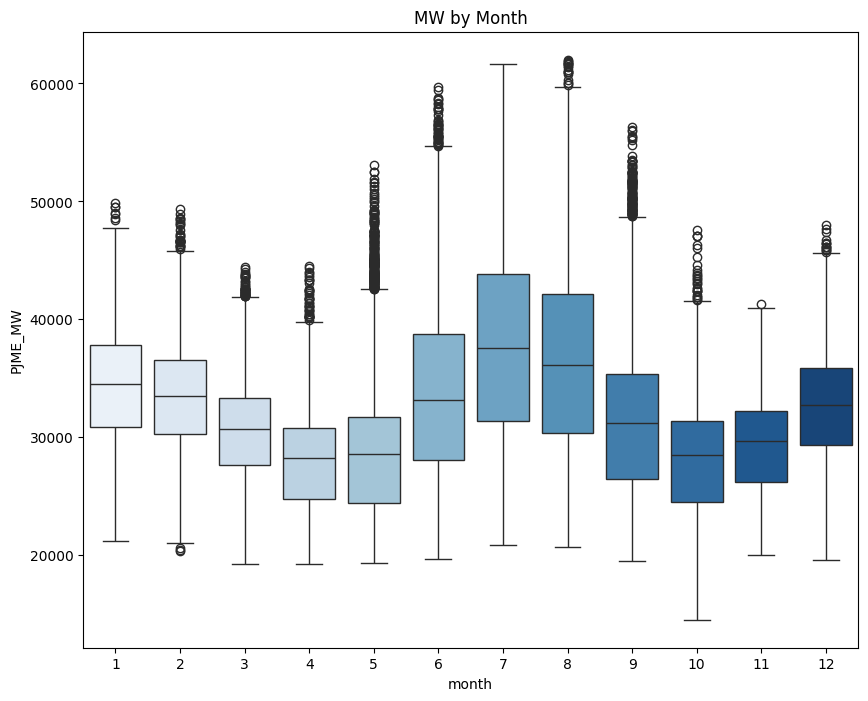

In [57]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

## Construct Model

In [58]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = train[FEATURES]
y_test = train[TARGET]

In [59]:
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_round=50,
                       learning_rate=0.001)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=True)

[0]	validation_0-rmse:6447.78573	validation_1-rmse:6447.78573
[1]	validation_0-rmse:6443.29274	validation_1-rmse:6443.29274
[2]	validation_0-rmse:6438.80544	validation_1-rmse:6438.80544
[3]	validation_0-rmse:6434.32403	validation_1-rmse:6434.32403
[4]	validation_0-rmse:6429.84843	validation_1-rmse:6429.84843
[5]	validation_0-rmse:6425.37887	validation_1-rmse:6425.37887
[6]	validation_0-rmse:6420.91495	validation_1-rmse:6420.91495
[7]	validation_0-rmse:6416.45698	validation_1-rmse:6416.45698
[8]	validation_0-rmse:6412.00500	validation_1-rmse:6412.00500
[9]	validation_0-rmse:6407.55851	validation_1-rmse:6407.55851
[10]	validation_0-rmse:6403.11804	validation_1-rmse:6403.11804
[11]	validation_0-rmse:6398.68322	validation_1-rmse:6398.68322
[12]	validation_0-rmse:6394.26025	validation_1-rmse:6394.26025
[13]	validation_0-rmse:6389.83693	validation_1-rmse:6389.83693
[14]	validation_0-rmse:6385.41956	validation_1-rmse:6385.41956
[15]	validation_0-rmse:6381.01416	validation_1-rmse:6381.01416
[1

e:\Python practice\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:12:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "early_stopping_round" } are not used.

  warnings.warn(smsg, UserWarning)


[17]	validation_0-rmse:6372.20806	validation_1-rmse:6372.20806
[18]	validation_0-rmse:6367.81983	validation_1-rmse:6367.81983
[19]	validation_0-rmse:6363.43097	validation_1-rmse:6363.43097
[20]	validation_0-rmse:6359.04793	validation_1-rmse:6359.04793
[21]	validation_0-rmse:6354.67662	validation_1-rmse:6354.67662
[22]	validation_0-rmse:6350.30499	validation_1-rmse:6350.30499
[23]	validation_0-rmse:6345.94522	validation_1-rmse:6345.94522
[24]	validation_0-rmse:6341.58505	validation_1-rmse:6341.58505
[25]	validation_0-rmse:6337.23058	validation_1-rmse:6337.23058
[26]	validation_0-rmse:6332.88773	validation_1-rmse:6332.88773
[27]	validation_0-rmse:6328.54458	validation_1-rmse:6328.54458
[28]	validation_0-rmse:6324.20715	validation_1-rmse:6324.20715
[29]	validation_0-rmse:6319.87950	validation_1-rmse:6319.87950
[30]	validation_0-rmse:6315.55353	validation_1-rmse:6315.55353
[31]	validation_0-rmse:6311.23144	validation_1-rmse:6311.23144
[32]	validation_0-rmse:6306.92059	validation_1-rmse:630

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_round=50,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.001, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Feature Importance

In [60]:
from sklearn.metrics import mean_squared_error

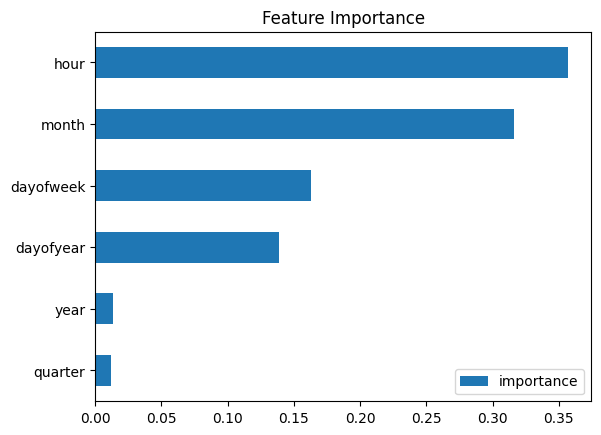

In [61]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

In [62]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

ValueError: Length of values (113926) does not match length of index (31440)

KeyError: 'prediction'

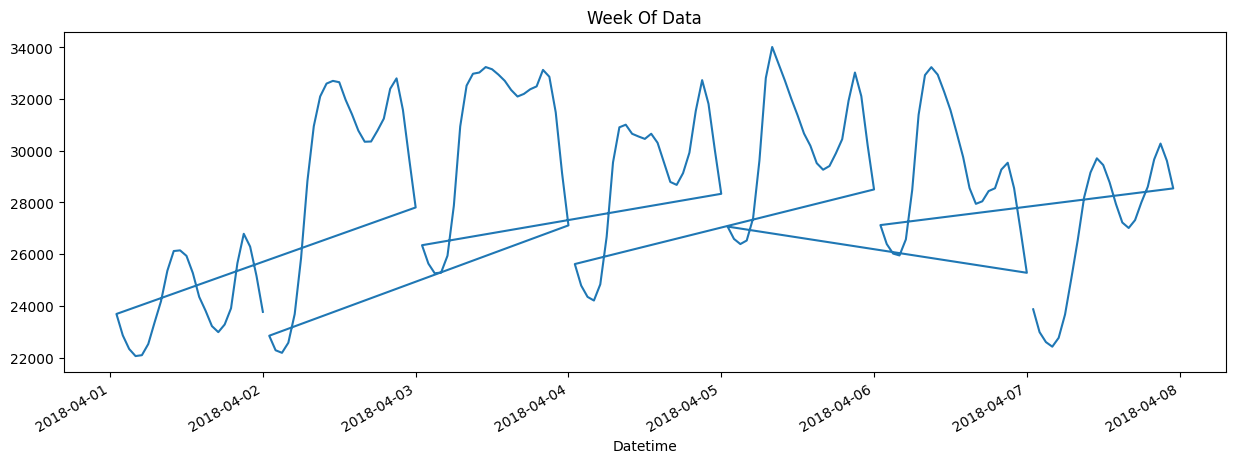

In [ ]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()